<a href="https://colab.research.google.com/github/Anthonerp/HoangIntroToMachineLearning/blob/main/Extra_Credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import torch
import torchvision
from torchvision import models
from torchvision.models import MobileNet_V2_Weights
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("GPU available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
GPU available: True
Device: cuda


In [37]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained MobileNetV2
weights = MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)
model = model.to(device)
model.eval()

# Preprocessing pipeline and class labels
preprocess = weights.transforms()
class_names = weights.meta["categories"]

print("Model loaded successfully.")
print("Number of ImageNet classes:", len(class_names))

Model loaded successfully.
Number of ImageNet classes: 1000


In [38]:
from google.colab import files
from PIL import Image

uploaded = files.upload()

images = {}
name_map = {
    "gecko.jpg": "Gecko",
    "snake.jpg": "Snake",
    "turtle.jpg": "Turtle"
}

for filename in uploaded:
    display_name = name_map.get(filename.lower(), filename.rsplit(".", 1)[0])
    images[display_name] = Image.open(filename).convert("RGB")

print("Loaded images:", list(images.keys()))

Saving turtle.jpg to turtle.jpg
Saving snake.jpg to snake.jpg
Saving gecko.jpg to gecko.jpg
Loaded images: ['Turtle', 'Snake', 'Gecko']


In [39]:
def predict_top5(image, model, preprocess, class_names, device):
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)

    top5_probs, top5_indices = torch.topk(probabilities, 5)

    results = []
    for prob, idx in zip(top5_probs.cpu().numpy(), top5_indices.cpu().numpy()):
        results.append((class_names[idx], float(prob)))
    return results

In [40]:
def show_image_with_predictions(title, image, predictions):
    fig = plt.figure(figsize=(12, 5))

    # Show image
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(image)
    ax1.set_title(title, fontsize=14)
    ax1.axis("off")

    # Show prediction text
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.axis("off")

    lines = [f"Top-5 Predictions for: {title}\n"]
    for i, (label, prob) in enumerate(predictions, start=1):
        lines.append(f"{i}. {label}: {prob*100:.2f}%")

    ax2.text(
        0.0, 1.0,
        "\n".join(lines),
        fontsize=13,
        va="top",
        family="monospace"
    )

    plt.tight_layout()
    plt.show()

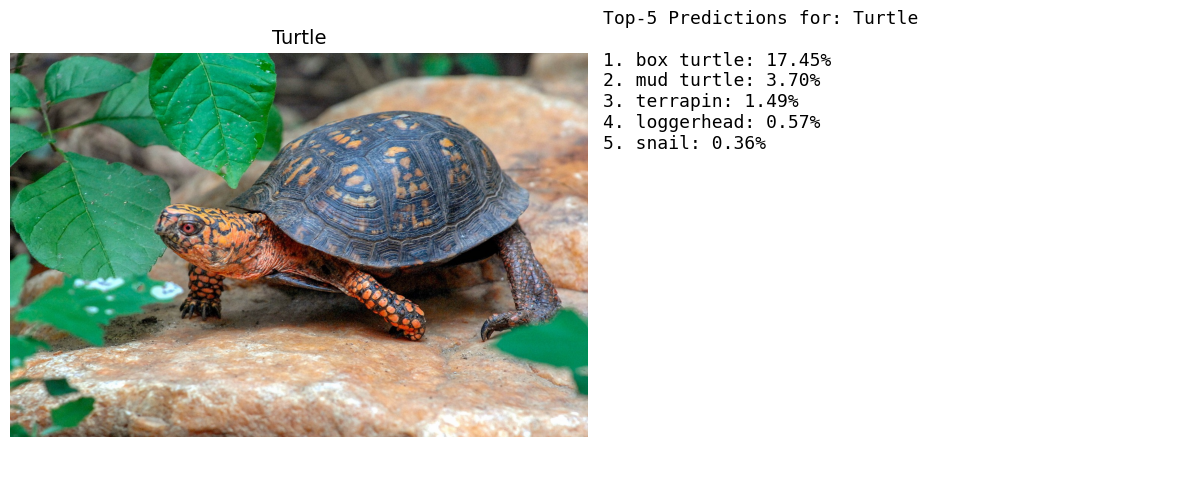

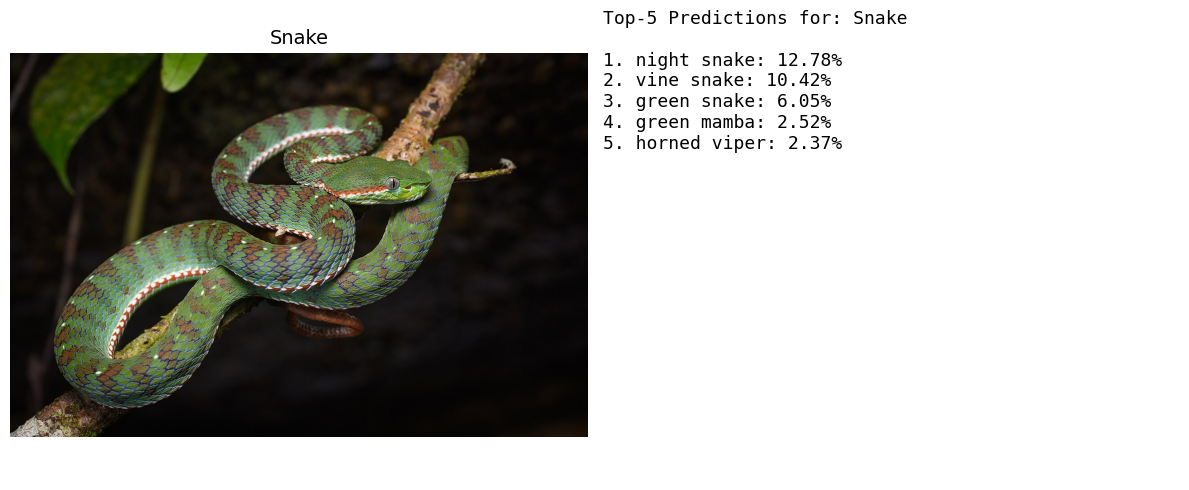

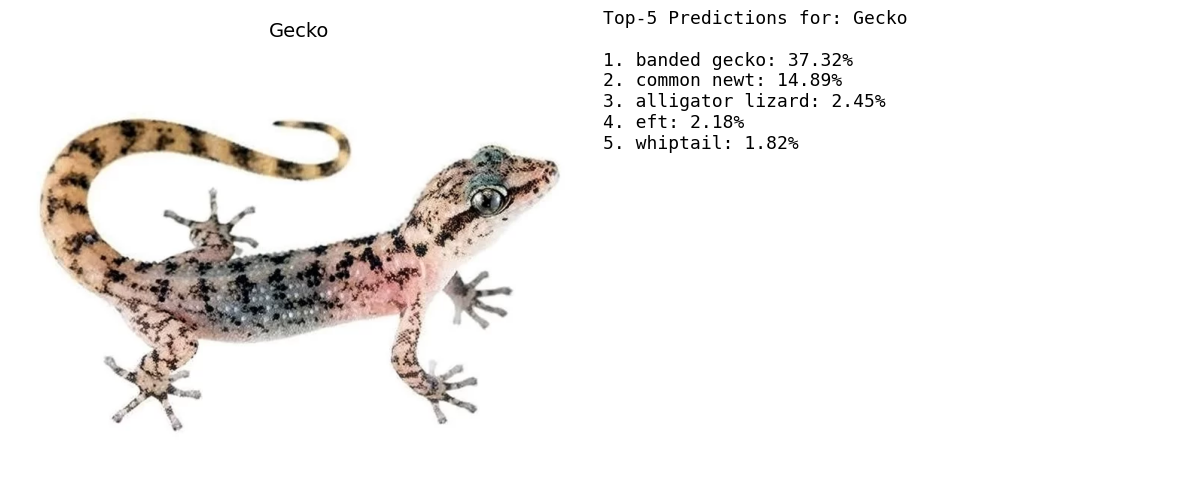

In [41]:
all_results = {}

for title, image in images.items():
    preds = predict_top5(image, model, preprocess, class_names, device)
    all_results[title] = preds
    show_image_with_predictions(title, image, preds)

In [42]:
# Print results in plain text too
for title, preds in all_results.items():
    print(f"\n=== {title} ===")
    for rank, (label, prob) in enumerate(preds, start=1):
        print(f"{rank}. {label}: {prob*100:.2f}%")


=== Turtle ===
1. box turtle: 17.45%
2. mud turtle: 3.70%
3. terrapin: 1.49%
4. loggerhead: 0.57%
5. snail: 0.36%

=== Snake ===
1. night snake: 12.78%
2. vine snake: 10.42%
3. green snake: 6.05%
4. green mamba: 2.52%
5. horned viper: 2.37%

=== Gecko ===
1. banded gecko: 37.32%
2. common newt: 14.89%
3. alligator lizard: 2.45%
4. eft: 2.18%
5. whiptail: 1.82%
